<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment No. 08: Random Forest and Boosting Comparison
### Roll No: 24/CS/232

---

### **Aim:**
To implement and compare Decision Tree, Random Forest, AdaBoost, and Gradient Boosting regression models, and analyze their performance, stability, training time, and feature importance using cross-validation.

### **Objectives:**
After completing this experiment, students will be able to:
1. Understand the concept of **ensemble learning**.
2. Understand **bagging** and **boosting** techniques.
3. Implement a **Decision Tree Regressor** as a baseline model.
4. Implement a **Random Forest Regressor** using multiple decision trees.
5. Implement **AdaBoost** and **Gradient Boosting** regressors.
6. Compare the models using **5-fold cross-validation**.
7. Measure the **training time** of different ensemble methods.
8. Analyze the **stability** of models using cross-validation standard deviation.
9. Investigate **feature importance** in Random Forest and Boosting models.
10. Recommend the most suitable model based on performance, stability, training time, and interpretability.

### **Pseudo Algorithm / Steps:**
1. **Start**
2. **Load** the house-price dataset.
3. **Inspect** the dataset and identify features and target.
4. **Handle missing values** and unnecessary columns.
5. **Separate** the features $X$ and target $y$.
6. **Split** the data into training and testing sets.
7. **Create** a Decision Tree Regressor.
8. **Create** a Random Forest Regressor.
9. **Create** an AdaBoost Regressor.
10. **Create** a Gradient Boosting Regressor.
11. **Train** each model using the training dataset.
12. **Perform 5-fold cross-validation** on the training data.
13. **Calculate** the cross-validation mean and standard deviation.
14. **Measure** the training time of each model.
15. **Compare** the models based on RMSE/MSE or $R^2$.
16. **Train** Random Forest on the complete training data.
17. **Extract and sort** Random Forest feature importances.
18. **Extract** feature importance from the boosting model.
19. **Compare** model performance, stability, training time, and interpretability.
20. **Select** the most suitable model.
21. **Stop**

**1. Loading the Dataset & Identifying Features (Steps 1–3)**

* **Dataset:** Housing Price Prediction dataset loaded directly from GitHub (`Housing.csv`).
* **Target Variable ($y$):** `price` (Continuous variable in Indian Rupees $\rightarrow$ Regression Task).
* **Feature Columns ($X$):**
  * *Numerical Predictors:* `area`, `bedrooms`, `bathrooms`, `stories`, `parking`.
  * *Binary Categorical Predictors:* `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea` (all `yes`/`no` values).
  * *Nominal Categorical Predictor:* `furnishingstatus` (`furnished`, `semi-furnished`, `unfurnished`).

In [ ]:
# import required libraries
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor
warnings.filterwarnings('ignore')

# load housing dataset directly from the github url
url = 'https://raw.githubusercontent.com/JyRaGa/CS303-Machine-Learning_Coursework/refs/heads/main/datasets/Housing.csv'
df = pd.read_csv(url)

# inspect dataset dimensions and initial records
print(f'dataset shape: {df.shape}')
df.info()
df.head()

dataset shape: (545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**2. Data Preprocessing & Train-Test Split (Steps 4–6)**

* **Missing Value Check:** Verified there are no null values in the dataset.
* **Categorical Encoding:** Applied `pd.get_dummies()` with `drop_first=True` to convert binary and nominal categorical variables into numeric dummy columns without multicollinearity.
* **Dataset Partitioning:** Separated features $X$ and target $y$, then split into **80% Training** and **20% Testing** sets with fixed `random_state=42` for reproducible benchmarking.
* **Cross-Validation Setup:** Configured 5-fold cross-validation with shuffling using `KFold(n_splits=5, shuffle=True, random_state=42)`.

In [ ]:
# check for missing values across columns
print('missing values check:')
print(df.isnull().sum())

# one-hot encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

# separate features and target variable
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\ntraining set shape: {X_train.shape}, testing set shape: {X_test.shape}')

# 5-fold cross validation configuration
kf = KFold(n_splits=5, shuffle=True, random_state=42)

missing values check:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

training set shape: (436, 13), testing set shape: (109, 13)


**3. Baseline Model: Decision Tree Regressor (Steps 7, 11–14)**

* **Model Type:** Single Decision Tree Regressor (`DecisionTreeRegressor(random_state=42)`).
* **Role:** Serves as our non-ensemble baseline model.
* **Characteristics:** Splits feature space recursively using Mean Squared Error reduction. Individual trees are fast but prone to high variance and sensitive to training data perturbations.
* **Validation:** Evaluated using **5-fold cross-validation** to record CV RMSE Mean, standard deviation (stability), and training time (averaged over 5 fits).

In [ ]:
# initialize decision tree regressor
dt_model = DecisionTreeRegressor(random_state=42)

# measure training time (averaged over 5 fits to reduce timing noise)
start_time = time.perf_counter()
for _ in range(5):
    dt_model.fit(X_train, y_train)
dt_train_time = (time.perf_counter() - start_time) / 5

# perform 5-fold cross validation
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
dt_cv_rmse = -dt_cv_scores
dt_cv_mean = dt_cv_rmse.mean()
dt_cv_std = dt_cv_rmse.std()

# evaluate on unseen test data
dt_y_pred = dt_model.predict(X_test)
dt_test_rmse = np.sqrt(mean_squared_error(y_test, dt_y_pred))
dt_test_r2 = r2_score(y_test, dt_y_pred)
dt_test_mae = mean_absolute_error(y_test, dt_y_pred)

# print decision tree results
print('=' * 55)
print('DECISION TREE REGRESSOR (BASELINE)')
print('=' * 55)
print(f'training time       : {dt_train_time:.4f} s')
print(f'5-fold cv rmse mean : {dt_cv_mean:,.2f}')
print(f'5-fold cv rmse std  : {dt_cv_std:,.2f}')
print(f'test rmse           : {dt_test_rmse:,.2f}')
print(f'test mae            : {dt_test_mae:,.2f}')
print(f'test r2 score       : {dt_test_r2:.4f}')
print('=' * 55)

DECISION TREE REGRESSOR (BASELINE)
training time       : 0.0027 s
5-fold cv rmse mean : 1,510,415.84
5-fold cv rmse std  : 214,760.24
test rmse           : 1,625,669.90
test mae            : 1,195,266.06
test r2 score       : 0.4771


**4. Bagging Ensemble: Random Forest Regressor (Steps 8, 11–14)**

* **Model Type:** Random Forest Regressor (`RandomForestRegressor(n_estimators=100, max_features='sqrt', random_state=42)`).
* **Bagging Concept:** Uses **Bootstrap Aggregating** to train 100 parallel decision trees on different random bootstrap subsets of the training data.
* **Feature Randomization:** `max_features='sqrt'` makes each split consider only a random subset of $\sqrt{p}$ features, decorrelating individual trees. (Note: scikit-learn's regressor default is `max_features=1.0`, i.e. all features, which would reduce the model to plain bagged trees, so it is set explicitly here.)
* **Variance Reduction:** Averaging predictions across trees reduces prediction variance while keeping bias low.

In [ ]:
# initialize random forest regressor
rf_model = RandomForestRegressor(n_estimators=100, max_features='sqrt', random_state=42)

# measure training time (averaged over 5 fits to reduce timing noise)
start_time = time.perf_counter()
for _ in range(5):
    rf_model.fit(X_train, y_train)
rf_train_time = (time.perf_counter() - start_time) / 5

# perform 5-fold cross validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rf_cv_rmse = -rf_cv_scores
rf_cv_mean = rf_cv_rmse.mean()
rf_cv_std = rf_cv_rmse.std()

# evaluate on unseen test data
rf_y_pred = rf_model.predict(X_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_test_r2 = r2_score(y_test, rf_y_pred)
rf_test_mae = mean_absolute_error(y_test, rf_y_pred)

# print random forest results
print('=' * 55)
print('RANDOM FOREST REGRESSOR (BAGGING)')
print('=' * 55)
print(f'training time       : {rf_train_time:.4f} s')
print(f'5-fold cv rmse mean : {rf_cv_mean:,.2f}')
print(f'5-fold cv rmse std  : {rf_cv_std:,.2f}')
print(f'test rmse           : {rf_test_rmse:,.2f}')
print(f'test mae            : {rf_test_mae:,.2f}')
print(f'test r2 score       : {rf_test_r2:.4f}')
print('=' * 55)

RANDOM FOREST REGRESSOR (BAGGING)
training time       : 0.1040 s
5-fold cv rmse mean : 1,048,525.04
5-fold cv rmse std  : 82,392.26
test rmse           : 1,392,203.02
test mae            : 1,012,480.10
test r2 score       : 0.6165


**5. Boosting Ensemble 1: AdaBoost Regressor (Steps 9, 11–14)**

* **Model Type:** Adaptive Boosting Regressor (`AdaBoostRegressor(n_estimators=100, random_state=42)`).
* **Boosting Paradigm:** Sequentially builds an ensemble of weak learners. In each successive round, instance weights are updated based on prediction errors so that hard-to-predict samples receive higher priority.
* **Aggregation:** Combines individual tree predictions using a **weighted median** of the trees' predictions (AdaBoost.R2), where better trees get larger weights.

In [ ]:
# initialize adaboost regressor
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)

# measure training time (averaged over 5 fits to reduce timing noise)
start_time = time.perf_counter()
for _ in range(5):
    ada_model.fit(X_train, y_train)
ada_train_time = (time.perf_counter() - start_time) / 5

# perform 5-fold cross validation
ada_cv_scores = cross_val_score(ada_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
ada_cv_rmse = -ada_cv_scores
ada_cv_mean = ada_cv_rmse.mean()
ada_cv_std = ada_cv_rmse.std()

# evaluate on unseen test data
ada_y_pred = ada_model.predict(X_test)
ada_test_rmse = np.sqrt(mean_squared_error(y_test, ada_y_pred))
ada_test_r2 = r2_score(y_test, ada_y_pred)
ada_test_mae = mean_absolute_error(y_test, ada_y_pred)

# print adaboost results
print('=' * 55)
print('ADABOOST REGRESSOR (BOOSTING)')
print('=' * 55)
print(f'training time       : {ada_train_time:.4f} s')
print(f'5-fold cv rmse mean : {ada_cv_mean:,.2f}')
print(f'5-fold cv rmse std  : {ada_cv_std:,.2f}')
print(f'test rmse           : {ada_test_rmse:,.2f}')
print(f'test mae            : {ada_test_mae:,.2f}')
print(f'test r2 score       : {ada_test_r2:.4f}')
print('=' * 55)

ADABOOST REGRESSOR (BOOSTING)
training time       : 0.1117 s
5-fold cv rmse mean : 1,173,374.76
5-fold cv rmse std  : 114,233.81
test rmse           : 1,524,360.14
test mae            : 1,156,790.93
test r2 score       : 0.5403


**6. Boosting Ensemble 2: Gradient Boosting Regressor (Steps 10, 11–14)**

* **Model Type:** Gradient Tree Boosting Regressor (`GradientBoostingRegressor(n_estimators=100, random_state=42)`).
* **Optimization Principle:** Gradient Boosting trains trees iteratively where each new tree fits directly to the **negative gradient (pseudo-residuals)** of the loss function with respect to current predictions.
* **Performance:** Provides fine-grained loss minimization through gradient descent steps in function space.

In [ ]:
# initialize gradient boosting regressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# measure training time (averaged over 5 fits to reduce timing noise)
start_time = time.perf_counter()
for _ in range(5):
    gb_model.fit(X_train, y_train)
gb_train_time = (time.perf_counter() - start_time) / 5

# perform 5-fold cross validation
gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
gb_cv_rmse = -gb_cv_scores
gb_cv_mean = gb_cv_rmse.mean()
gb_cv_std = gb_cv_rmse.std()

# evaluate on unseen test data
gb_y_pred = gb_model.predict(X_test)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_y_pred))
gb_test_r2 = r2_score(y_test, gb_y_pred)
gb_test_mae = mean_absolute_error(y_test, gb_y_pred)

# print gradient boosting results
print('=' * 55)
print('GRADIENT BOOSTING REGRESSOR (BOOSTING)')
print('=' * 55)
print(f'training time       : {gb_train_time:.4f} s')
print(f'5-fold cv rmse mean : {gb_cv_mean:,.2f}')
print(f'5-fold cv rmse std  : {gb_cv_std:,.2f}')
print(f'test rmse           : {gb_test_rmse:,.2f}')
print(f'test mae            : {gb_test_mae:,.2f}')
print(f'test r2 score       : {gb_test_r2:.4f}')
print('=' * 55)

GRADIENT BOOSTING REGRESSOR (BOOSTING)
training time       : 0.0610 s
5-fold cv rmse mean : 1,082,711.07
5-fold cv rmse std  : 47,471.34
test rmse           : 1,299,385.98
test mae            : 959,748.96
test r2 score       : 0.6660


**7. Comprehensive Cross-Validation Comparison & Model Stability Analysis (Steps 15, 19)**

* **Evaluation Metrics:**
  * **CV RMSE Mean:** Primary indicator of generalization error across all folds.
  * **CV RMSE Std:** Indicator of model stability; lower standard deviation indicates that the model performance is consistent across different data subsets.
  * **Test RMSE & $R^2$:** Validation on previously unseen test records.
  * **Training Time:** Average of 5 fits on the training set (absolute values depend on the machine; the relative ordering is what matters).

=== MODEL COMPARISON TABLE ===
            Model  CV RMSE Mean   CV RMSE Std    Test RMSE  Test R2  Training Time (s)
    Decision Tree  1.510416e+06 214760.244947 1.625670e+06 0.477146           0.002669
    Random Forest  1.048525e+06  82392.258896 1.392203e+06 0.616539           0.103993
         AdaBoost  1.173375e+06 114233.808954 1.524360e+06 0.540283           0.111670
Gradient Boosting  1.082711e+06  47471.335345 1.299386e+06 0.665965           0.060972


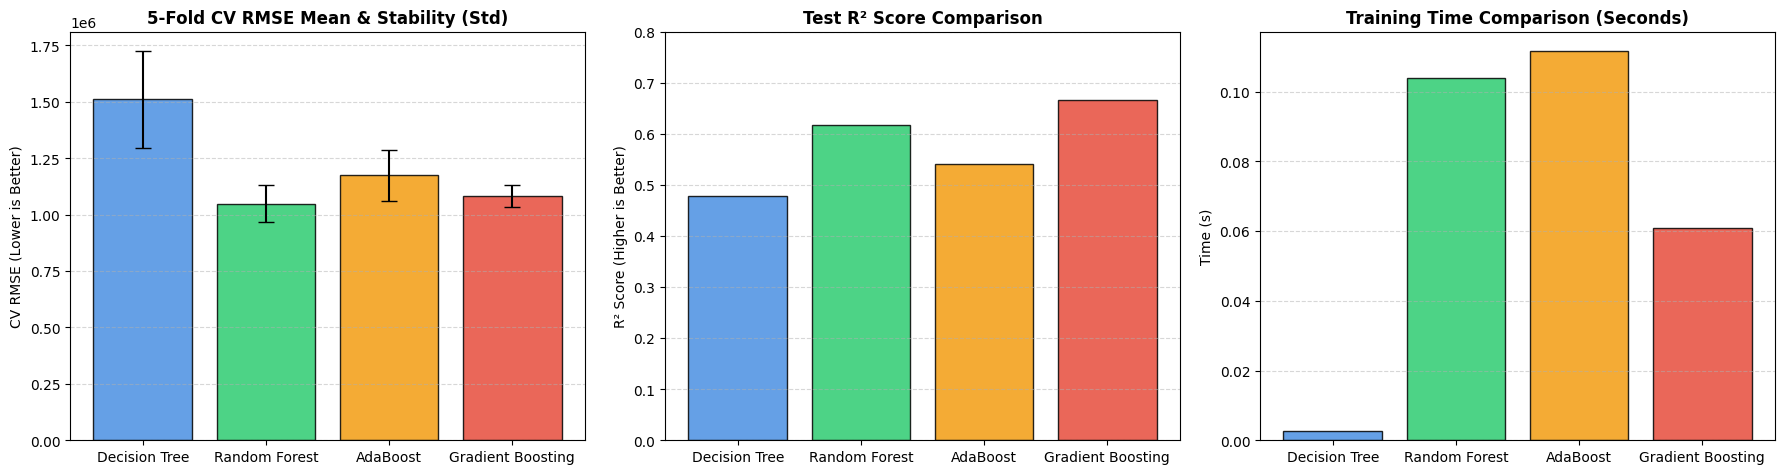

In [ ]:
# consolidate all evaluation metrics into comparison table
summary_data = [
    {'Model': 'Decision Tree', 'CV RMSE Mean': dt_cv_mean, 'CV RMSE Std': dt_cv_std, 'Test RMSE': dt_test_rmse, 'Test R2': dt_test_r2, 'Training Time (s)': dt_train_time},
    {'Model': 'Random Forest', 'CV RMSE Mean': rf_cv_mean, 'CV RMSE Std': rf_cv_std, 'Test RMSE': rf_test_rmse, 'Test R2': rf_test_r2, 'Training Time (s)': rf_train_time},
    {'Model': 'AdaBoost', 'CV RMSE Mean': ada_cv_mean, 'CV RMSE Std': ada_cv_std, 'Test RMSE': ada_test_rmse, 'Test R2': ada_test_r2, 'Training Time (s)': ada_train_time},
    {'Model': 'Gradient Boosting', 'CV RMSE Mean': gb_cv_mean, 'CV RMSE Std': gb_cv_std, 'Test RMSE': gb_test_rmse, 'Test R2': gb_test_r2, 'Training Time (s)': gb_train_time}
]

df_summary = pd.DataFrame(summary_data)
print('=== MODEL COMPARISON TABLE ===')
print(df_summary.to_string(index=False))

# plot 1: cv rmse mean with std error bars, r2 score, and training time
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4a90e2', '#2ecc71', '#f39c12', '#e74c3c']

# cv rmse with error bars
axes[0].bar(df_summary['Model'], df_summary['CV RMSE Mean'], yerr=df_summary['CV RMSE Std'], capsize=6, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('5-Fold CV RMSE Mean & Stability (Std)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('CV RMSE (Lower is Better)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# test r2 score comparison
axes[1].bar(df_summary['Model'], df_summary['Test R2'], color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Test R² Score Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score (Higher is Better)')
axes[1].set_ylim(0, 0.8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# training time comparison
axes[2].bar(df_summary['Model'], df_summary['Training Time (s)'], color=colors, alpha=0.85, edgecolor='black')
axes[2].set_title('Training Time Comparison (Seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Time (s)')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**8. Actual vs. Predicted House Prices Diagnostic Plots**

Visualizing test set actual prices against model predictions across all 4 models:
* The dashed red line represents the ideal reference ($y = x$).
* Closer alignment to the diagonal reflects superior predictive accuracy and lower variance.

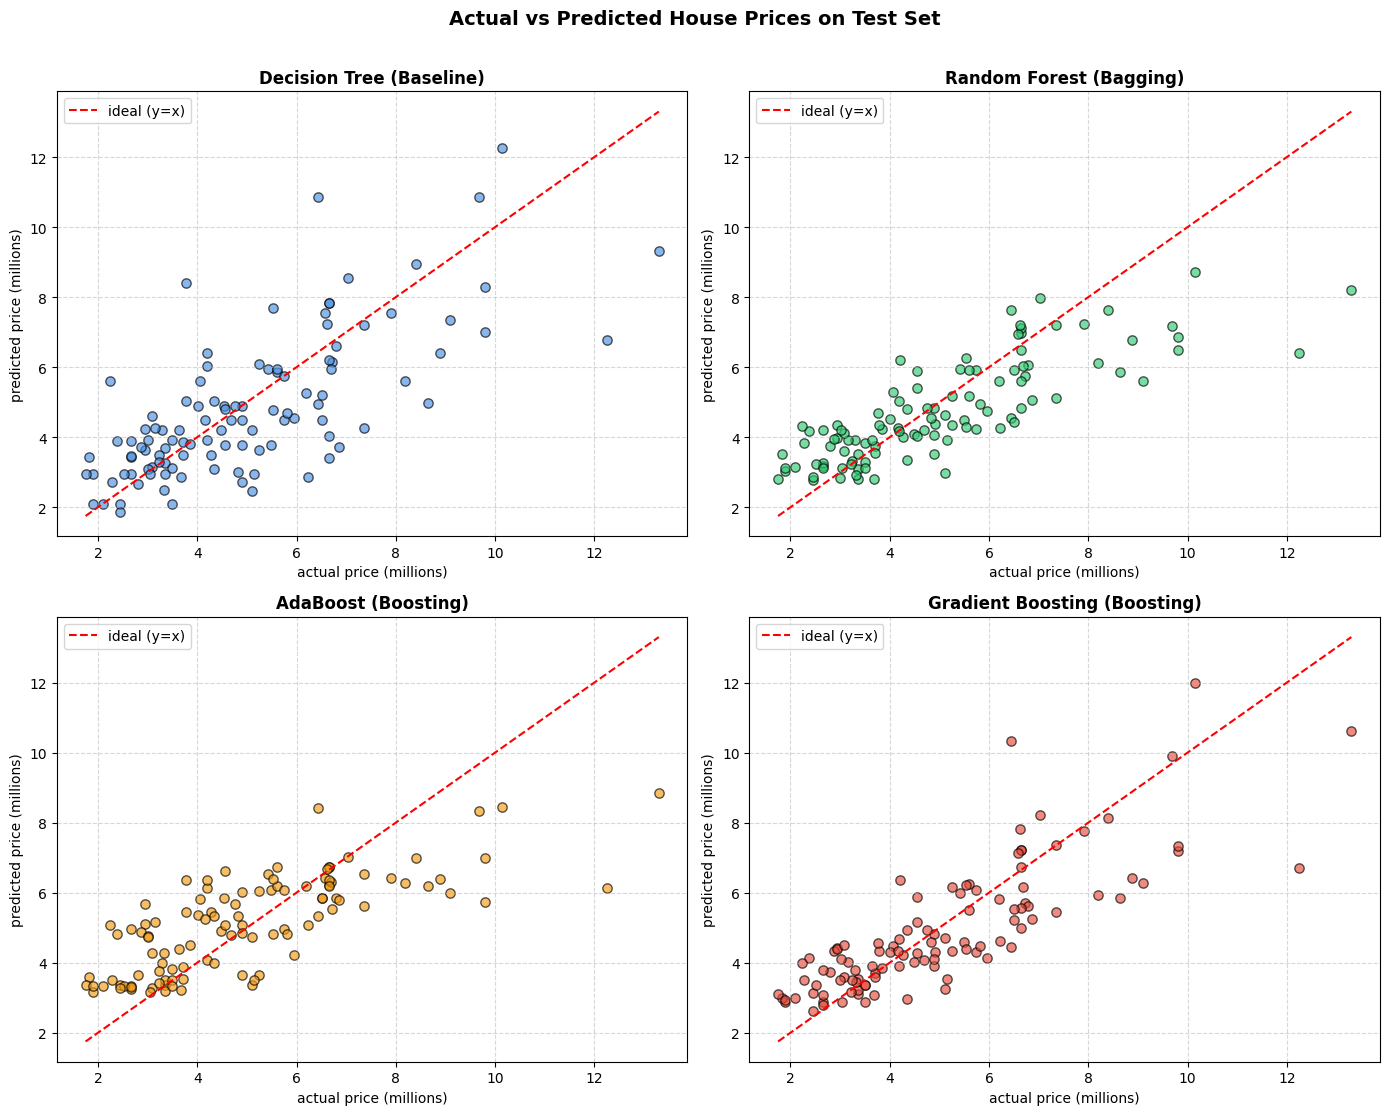

In [ ]:
# plot actual vs predicted prices across all models
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

models_preds = [
    ('Decision Tree (Baseline)', dt_y_pred, '#4a90e2'),
    ('Random Forest (Bagging)', rf_y_pred, '#2ecc71'),
    ('AdaBoost (Boosting)', ada_y_pred, '#f39c12'),
    ('Gradient Boosting (Boosting)', gb_y_pred, '#e74c3c')
]

for idx, (title, preds, col) in enumerate(models_preds):
    axes[idx].scatter(y_test / 1e6, preds / 1e6, color=col, alpha=0.65, edgecolors='k', s=45)
    min_val = min(y_test.min(), preds.min()) / 1e6
    max_val = max(y_test.max(), preds.max()) / 1e6
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='ideal (y=x)')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('actual price (millions)')
    axes[idx].set_ylabel('predicted price (millions)')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Actual vs Predicted House Prices on Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**9. Feature Importance Analysis: Random Forest vs. Gradient Boosting (Steps 16–18)**

* **Feature Importance Mechanism:** Tree-based models evaluate the total reduction of criterion (impurity/MSE) brought about by each feature across all split nodes.
* **Random Forest Importances:** Averaged across all 100 decorrelated trees.
* **Gradient Boosting Importances:** Weighted accumulation across sequential boosting stages.

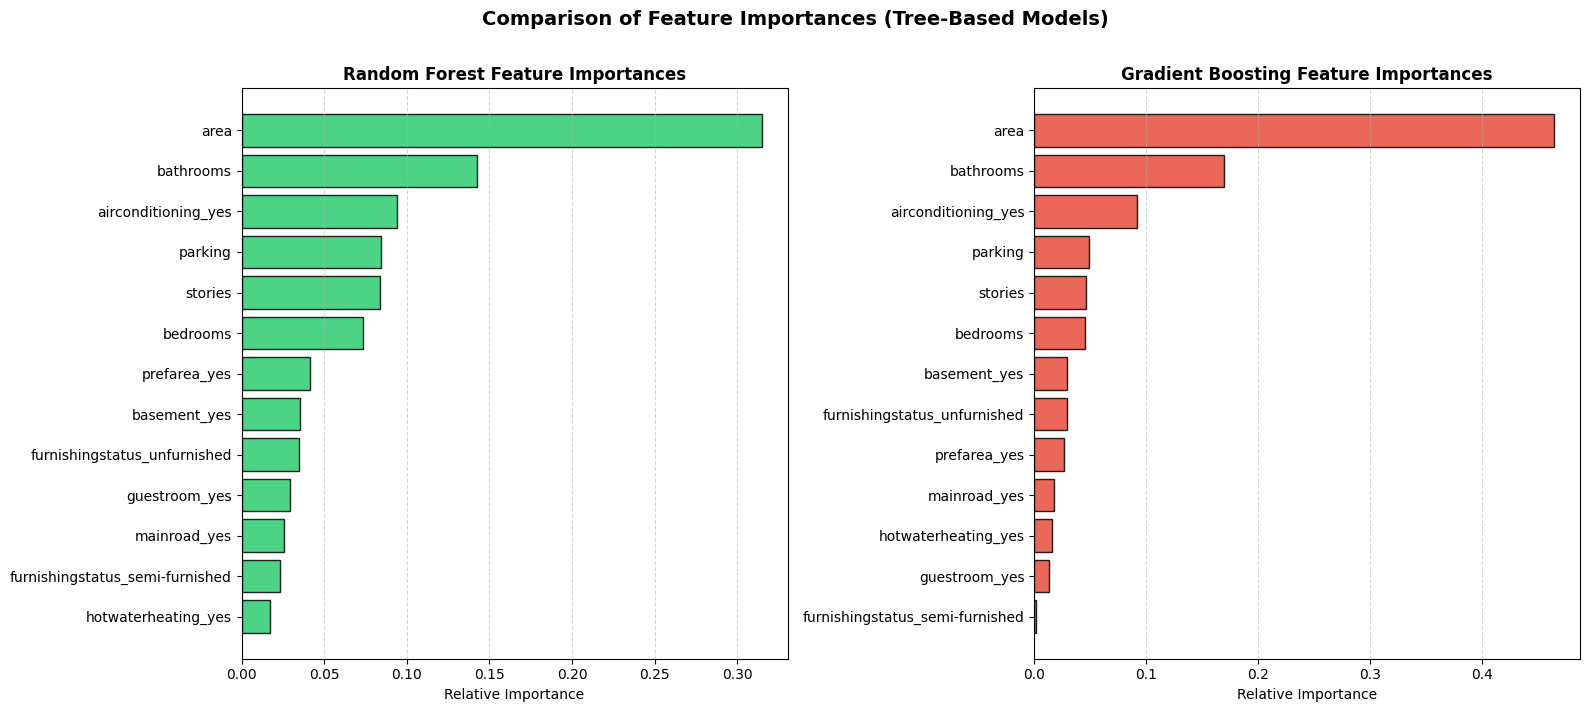

TOP 5 INFLUENTIAL FEATURES (RANDOM FOREST):
area                   0.314607
bathrooms              0.142637
airconditioning_yes    0.093928
parking                0.084560
stories                0.083454

TOP 5 INFLUENTIAL FEATURES (GRADIENT BOOSTING):
area                   0.464321
bathrooms              0.169201
airconditioning_yes    0.091497
parking                0.048649
stories                0.045925


In [ ]:
# extract and sort feature importances from random forest
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# extract and sort feature importances from gradient boosting
gb_importances = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# plot side-by-side horizontal bar chart of feature importances
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# random forest feature importances plot
axes[0].barh(rf_importances.index, rf_importances.values, color='#2ecc71', edgecolor='black', alpha=0.85)
axes[0].set_title('Random Forest Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Relative Importance')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# gradient boosting feature importances plot
axes[1].barh(gb_importances.index, gb_importances.values, color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('Gradient Boosting Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Relative Importance')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Comparison of Feature Importances (Tree-Based Models)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# display top 5 most influential predictors for both models
print('TOP 5 INFLUENTIAL FEATURES (RANDOM FOREST):')
print(rf_importances.sort_values(ascending=False).head(5).to_string())
print('\nTOP 5 INFLUENTIAL FEATURES (GRADIENT BOOSTING):')
print(gb_importances.sort_values(ascending=False).head(5).to_string())

**10. Results, Observations & Conclusion (Steps 19–21)**

### **Performance Summary & Comparison Table:**

| Model | 5-Fold CV RMSE Mean (₹) | 5-Fold CV RMSE Std (₹) | Test RMSE (₹) | Test $R^2$ Score | Training Time (s) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Decision Tree (Baseline)** | 1,510,415.84 | 214,760.24 | 1,625,669.90 | 0.4771 | ~0.003 s |
| **Random Forest (Bagging)** | 1,048,525.04 | 82,392.26 | 1,392,203.02 | 0.6165 | ~0.10 s |
| **AdaBoost (Boosting)** | 1,173,374.76 | 114,233.81 | 1,524,360.14 | 0.5403 | ~0.11 s |
| **Gradient Boosting (Boosting)** | 1,082,711.07 | 47,471.34 | 1,299,385.98 | 0.6660 | ~0.06 s |

*Training times are machine-dependent and will vary slightly between runs; see the comparison table output above for the exact values of this run.*

---

### **Observations:**
* **Baseline Decision Tree:** Simple and interpretable, but it has the highest CV RMSE mean (₹1,510,416) and by far the highest CV standard deviation (₹214,760), showing high variance and sensitivity to the data split.
* **Bagging (Random Forest):** Bootstrap sampling plus feature subsampling (`max_features='sqrt'`) gives the **lowest CV RMSE mean (₹1,048,525)** and cuts the CV standard deviation to ₹82,392, about 62% lower than the single tree.
* **Boosting (AdaBoost):** Sequential re-weighting of hard samples improves on the baseline tree (test $R^2$ 0.5403 vs 0.4771), but it is the weakest of the three ensembles here.
* **Boosting (Gradient Boosting):** Its CV RMSE mean (₹1,082,711) is about 3% higher than Random Forest's, a small gap given the fold-to-fold spread. It has the **lowest CV standard deviation (₹47,471)**, the **best test RMSE (₹1,299,386)** and the **highest test $R^2$ (0.6660)**.
* **Model Stability:** Lower CV standard deviation means more consistent performance across folds. Gradient Boosting (₹47,471) is the most stable, followed by Random Forest (₹82,392); both are far more stable than the single Decision Tree (₹214,760).
* **Computational Cost:** The single tree trains almost instantly. The ensembles take longer (Gradient Boosting ≈ 0.06 s, Random Forest ≈ 0.10 s, AdaBoost ≈ 0.11 s), which is a small cost for the gains in accuracy and stability on a dataset of this size.
* **Test vs CV Error:** Test RMSE is higher than CV RMSE for every model. The test set has only 109 houses, so a single test score is noisy; the 5-fold CV results are the more reliable basis for comparison.
* **Feature Importance Insights:** Both models rank `area` as the most influential feature (≈31% in Random Forest, ≈46% in Gradient Boosting), followed by `bathrooms` (≈14–17%), then `airconditioning`, `parking` and `stories`. Random Forest spreads importance more evenly because feature subsampling lets weaker features be chosen at splits more often.


### **Gradient Boosting Mechanism: Real Housing Data Residual Fitting & Ensemble Combinations**

To illustrate how **Gradient Boosting** builds its prediction on our Housing dataset, the following visualization plots the sequential stage-by-stage boosting process directly using the primary predictor $x_1 = \text{area}$ and target $y = \text{price}$ (in millions ₹).

*Simplification: scikit-learn's `GradientBoostingRegressor` starts from the mean of $y$ and scales each tree by a learning rate (default 0.1). The demo below fits Tree 1 directly on $y$ and adds full-size trees so each stage is easy to see.*

| Subplot Position | Subplot Title | Ensemble Combination / Target | Mathematical Model |
| :--- | :--- | :--- | :--- |
| **Row 1, Left** | Residuals & Tree 1 ($h_1$) | Base learner $h_1$ fitted to real house prices | $h_1(x_1) \approx y$ |
| **Row 1, Right** | Ensemble Stage 1 | Single-tree baseline prediction | $h(x_1) = h_1(x_1)$ |
| **Row 2, Left** | Residuals & Tree 2 ($h_2$) | Second tree trained on stage 1 unexplained errors | $h_2(x_1) \approx y - h_1(x_1)$ |
| **Row 2, Right** | Ensemble Stage 2 Combo | Two-tree ensemble combining $h_1 + h_2$ | $h(x_1) = h_1(x_1) + h_2(x_1)$ |
| **Row 3, Left** | Residuals & Tree 3 ($h_3$) | Third tree trained on stage 2 remaining errors | $h_3(x_1) \approx y - h_1(x_1) - h_2(x_1)$ |
| **Row 3, Right** | Ensemble Stage 3 Combo | Three-tree ensemble combining $h_1 + h_2 + h_3$ | $h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$ |

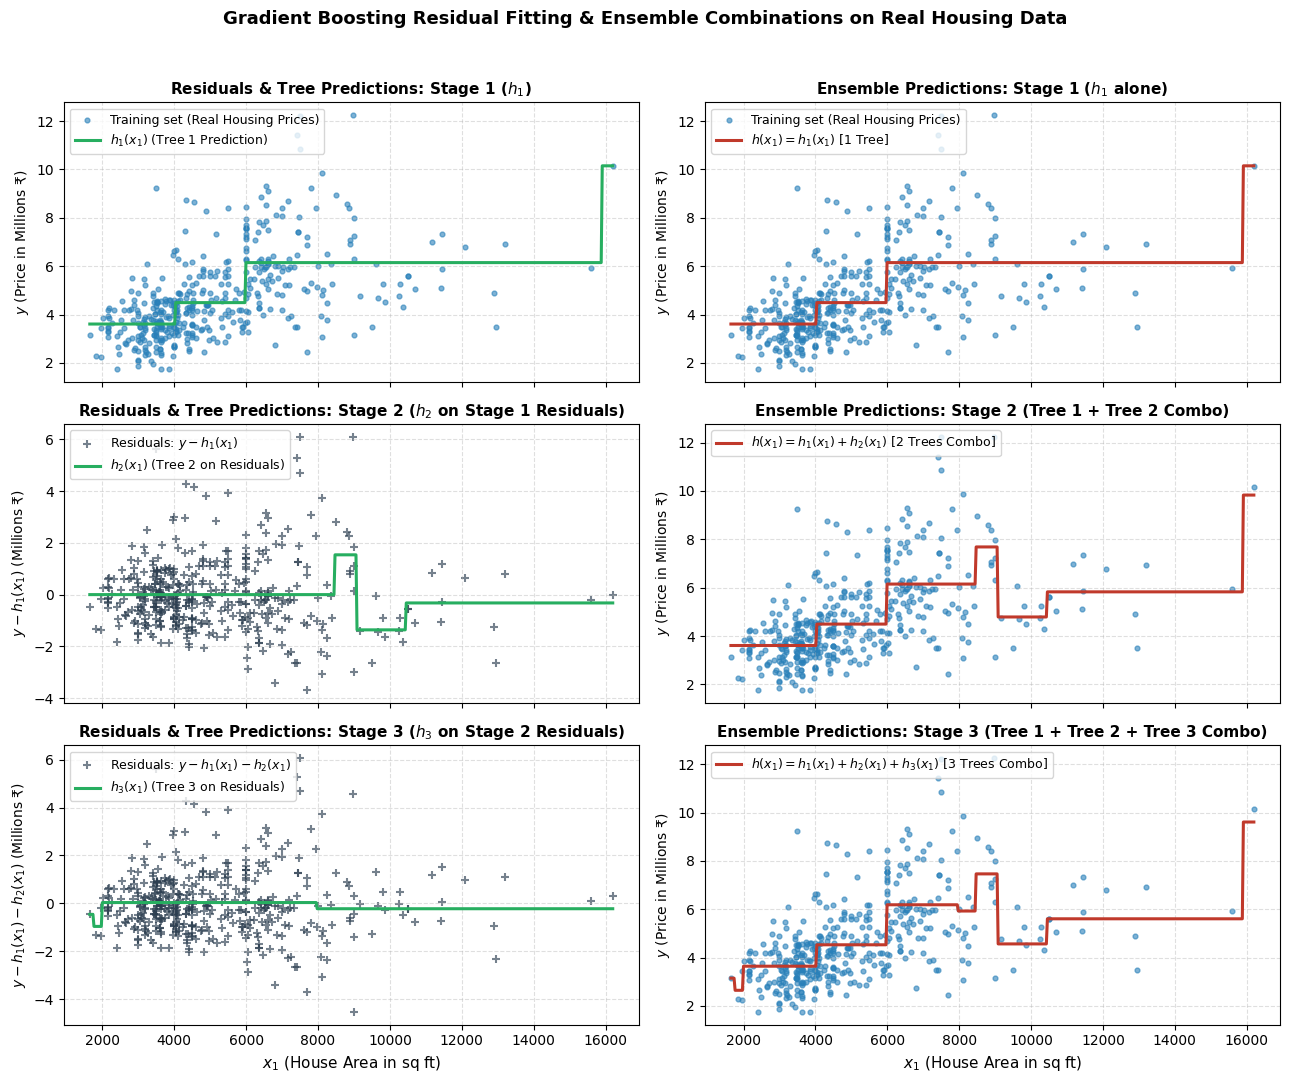

In [ ]:
# use real housing training data with primary feature area as x1 and price as y
x_area = X_train[['area']].values
y_price = y_train.values / 1e6

# sort by area for smooth continuous step visualization
sort_idx = np.argsort(x_area.flatten())
x_sort = x_area[sort_idx]
y_sort = y_price[sort_idx]

# stage 1: fit initial tree on real house prices
tree1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree1.fit(x_sort, y_sort)

# stage 2: compute residuals from tree 1 and fit tree 2
r1 = y_sort - tree1.predict(x_sort)
tree2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree2.fit(x_sort, r1)

# stage 3: compute residuals from tree 2 and fit tree 3
r2 = r1 - tree2.predict(x_sort)
tree3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree3.fit(x_sort, r2)

# evaluation domain mesh across area range
x_grid = np.linspace(x_sort.min(), x_sort.max(), 500).reshape(-1, 1)
y_p1 = tree1.predict(x_grid)
y_p2 = tree2.predict(x_grid)
y_p3 = tree3.predict(x_grid)

# create 3x2 grid showing residuals and ensemble combinations
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)

# row 1: stage 1 tree 1 prediction and 1-tree ensemble
axes[0, 0].scatter(x_sort, y_sort, color='#2980b9', s=12, alpha=0.6, label='Training set (Real Housing Prices)')
axes[0, 0].plot(x_grid, y_p1, color='#27ae60', linewidth=2.2, label='$h_1(x_1)$ (Tree 1 Prediction)')
axes[0, 0].set_title('Residuals & Tree Predictions: Stage 1 ($h_1$)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('$y$ (Price in Millions ₹)', fontsize=10)
axes[0, 0].legend(loc='upper left', frameon=True, fontsize=9)
axes[0, 0].grid(True, linestyle='--', alpha=0.4)

axes[0, 1].scatter(x_sort, y_sort, color='#2980b9', s=12, alpha=0.6, label='Training set (Real Housing Prices)')
axes[0, 1].plot(x_grid, y_p1, color='#c0392b', linewidth=2.2, label='$h(x_1) = h_1(x_1)$ [1 Tree]')
axes[0, 1].set_title('Ensemble Predictions: Stage 1 ($h_1$ alone)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('$y$ (Price in Millions ₹)', fontsize=10)
axes[0, 1].legend(loc='upper left', frameon=True, fontsize=9)
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

# row 2: stage 2 tree 2 on residuals and 2-tree ensemble combination
axes[1, 0].scatter(x_sort, r1, color='#2c3e50', marker='+', s=30, alpha=0.65, label='Residuals: $y - h_1(x_1)$')
axes[1, 0].plot(x_grid, y_p2, color='#27ae60', linewidth=2.2, label='$h_2(x_1)$ (Tree 2 on Residuals)')
axes[1, 0].set_title('Residuals & Tree Predictions: Stage 2 ($h_2$ on Stage 1 Residuals)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('$y - h_1(x_1)$ (Millions ₹)', fontsize=10)
axes[1, 0].legend(loc='upper left', frameon=True, fontsize=9)
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

axes[1, 1].scatter(x_sort, y_sort, color='#2980b9', s=12, alpha=0.6)
axes[1, 1].plot(x_grid, y_p1 + y_p2, color='#c0392b', linewidth=2.2, label='$h(x_1) = h_1(x_1) + h_2(x_1)$ [2 Trees Combo]')
axes[1, 1].set_title('Ensemble Predictions: Stage 2 (Tree 1 + Tree 2 Combo)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('$y$ (Price in Millions ₹)', fontsize=10)
axes[1, 1].legend(loc='upper left', frameon=True, fontsize=9)
axes[1, 1].grid(True, linestyle='--', alpha=0.4)

# row 3: stage 3 tree 3 on residuals and 3-tree ensemble combination
axes[2, 0].scatter(x_sort, r2, color='#2c3e50', marker='+', s=30, alpha=0.65, label='Residuals: $y - h_1(x_1) - h_2(x_1)$')
axes[2, 0].plot(x_grid, y_p3, color='#27ae60', linewidth=2.2, label='$h_3(x_1)$ (Tree 3 on Residuals)')
axes[2, 0].set_title('Residuals & Tree Predictions: Stage 3 ($h_3$ on Stage 2 Residuals)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('$y - h_1(x_1) - h_2(x_1)$ (Millions ₹)', fontsize=10)
axes[2, 0].set_xlabel('$x_1$ (House Area in sq ft)', fontsize=11)
axes[2, 0].legend(loc='upper left', frameon=True, fontsize=9)
axes[2, 0].grid(True, linestyle='--', alpha=0.4)

axes[2, 1].scatter(x_sort, y_sort, color='#2980b9', s=12, alpha=0.6)
axes[2, 1].plot(x_grid, y_p1 + y_p2 + y_p3, color='#c0392b', linewidth=2.2, label='$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$ [3 Trees Combo]')
axes[2, 1].set_title('Ensemble Predictions: Stage 3 (Tree 1 + Tree 2 + Tree 3 Combo)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('$y$ (Price in Millions ₹)', fontsize=10)
axes[2, 1].set_xlabel('$x_1$ (House Area in sq ft)', fontsize=11)
axes[2, 1].legend(loc='upper left', frameon=True, fontsize=9)
axes[2, 1].grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Gradient Boosting Residual Fitting & Ensemble Combinations on Real Housing Data', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### **Conclusion:**
* **Empirical Validation:** On the Housing dataset, all three ensembles beat the baseline Decision Tree. Random Forest achieved the lowest CV RMSE mean (₹1,048,525) by reducing variance through bootstrap sampling and feature randomisation. Gradient Boosting was close behind on CV RMSE (₹1,082,711) while giving the lowest CV standard deviation and the best test results ($R^2 = 0.6660$).
* **Mechanistic Insight:** As the residual plots above show, Gradient Boosting fits each new tree to the errors left by the earlier trees, so the ensemble prediction is corrected step by step.
* **Final Model Recommendation:** **Gradient Boosting Regressor** is recommended. Its CV RMSE is within ~3% of Random Forest's, and it is the most stable across folds, performs best on the held-out test set, and trains faster than both other ensembles. **Random Forest** is a close alternative if lowest average CV error is the only criterion.


In [ ]:
# save the selected model for deployment
import joblib

joblib.dump(gb_model, 'gradient_boosting_housing_model.pkl')
loaded_model = joblib.load('gradient_boosting_housing_model.pkl')
print('model saved and reloaded, test r2:', round(r2_score(y_test, loaded_model.predict(X_test)), 4))

model saved and reloaded, test r2: 0.666


**11. Viva Questions & Comprehensive Answers**

### **Q1. What is Ensemble learning?**
**Answer:** Ensemble learning is a machine learning paradigm where multiple individual models (called base learners or weak learners) are trained and combined to solve a common problem. By aggregating the predictions of diverse models (through averaging, voting, or weighted sum), ensemble methods achieve significantly better generalization performance, reduced variance, and lower risk of overfitting compared to any single constituent model.

---

### **Q2. What is the difference between Bagging and Boosting?**
**Answer:**
* **Bagging (Bootstrap Aggregating):**
  * **Architecture:** Trains base models **in parallel** and independently on different bootstrap subsets (random sampling with replacement).
  * **Primary Goal:** Reduces **variance** without increasing bias (ideal for high-variance, unconstrained models like deep decision trees).
  * **Aggregation:** Simple averaging (regression) or majority voting (classification).
  * **Example:** Random Forest.
* **Boosting:**
  * **Architecture:** Trains base models **sequentially** in stages, where each new model focuses on correcting the residual errors or misclassifications made by previous models.
  * **Primary Goal:** Reduces **bias** (as well as variance) by turning weak learners into a strong learner.
  * **Aggregation:** Weighted combination based on learner performance or gradient descent step size.
  * **Examples:** AdaBoost, Gradient Boosting, XGBoost, LightGBM.

---

### **Q3. How does Random Forest reduce overfitting compared with a single Decision Tree?**
**Answer:** A single unconstrained decision tree splits recursively until leaves are pure, leading to deep branches that fit specific noise and peculiarities of the training set (high variance/overfitting). Random Forest mitigates this via two levels of randomization:
1. **Bootstrap Aggregation:** Each tree is trained on a distinct bootstrap sample, exposing different trees to different subsets of data.
2. **Feature Subspace Randomization:** At every node split, only a random subset of $m \approx \sqrt{p}$ (or $p/3$) features is evaluated rather than all $p$ features (set via `max_features`; in scikit-learn's regressor this must be set explicitly, as the default uses all features). This **decorrelates** the trees so that a single dominant feature does not dominate every tree. When hundreds of decorrelated trees are averaged, individual errors cancel out, drastically lowering model variance.

---

### **Q4. Why do we use multiple trees in Random Forest?**
**Answer:** According to the Law of Large Numbers, the average of multiple independent and identically distributed random variables has lower variance than any single variable:
$$\text{Var}(\bar{X}) = \frac{\sigma^2}{B}$$
In Random Forest, because individual trees are partially correlated with correlation $\rho$, the total ensemble variance is:
$$\text{Var}(\text{Ensemble}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$
As the number of trees $B$ increases, the second term $\frac{1-\rho}{B}\sigma^2 \to 0$. Thus, using multiple trees stabilizes predictions, dampens noise, and ensures robust generalization without risking overfitting as $B$ grows.

---

### **Q5. What is the main idea behind Boosting?**
**Answer:** The fundamental philosophy behind boosting is that **"a committee of weak learners can combine into an exceptional strong learner."** Instead of building models independently, boosting trains models sequentially. Each successive model inspects the shortcomings (residuals or high-loss instances) of the combined preceding ensemble, assigning higher importance/gradients to these difficult cases so subsequent learners specifically rectify those mistakes.

---

### **Q6. What is the difference between AdaBoost and Gradient Boosting?**
**Answer:**
* **AdaBoost (Adaptive Boosting):**
  * For regression, scikit-learn uses **AdaBoost.R2**, which measures each sample's error with a linear, square or exponential loss (linear by default). The exponential-loss view of AdaBoost applies to classification.
  * Updates the **weights of individual training instances** at each iteration; harder-to-predict samples receive higher sample weights.
  * Combines the trees' predictions using a **weighted median**, where each tree's weight depends on its error.
* **Gradient Boosting:**
  * A generalized framework that can optimize **any differentiable loss function** (e.g., Mean Squared Error, Mean Absolute Error, Huber Loss).
  * Does **not** change data sample weights; instead, each subsequent tree directly fits the **negative gradient (pseudo-residuals)** of the loss function:
    $$r_{im} = -\left[ \frac{\partial L(y_i, \hat{y}_i)}{\partial \hat{y}_i} \right]$$
  * Treats boosting as functional gradient descent with a learning rate (shrinkage parameter $\eta$).

---

### **Q7. Why is cross-validation used in this experiment?**
**Answer:**
1. **Unbiased Performance Assessment:** Evaluating models on a single train-test split can introduce sample bias due to luck or unfortunate data partitioning. 5-fold cross-validation ensures every training-set point is used for validation exactly once.
2. **Assessing Stability & Robustness:** Cross-validation provides a distribution of performance scores across 5 distinct folds, allowing us to compute both the mean and standard deviation.
3. **Reliable Model Selection:** Allows fair comparison of different algorithmic families (Decision Tree, Bagging, Boosting) under uniform validation folds.

---

### **Q8. What does the standard deviation of cross-validation scores tell us?**
**Answer:** The standard deviation of cross-validation scores measures the **stability and consistency** of the model across different data subsets:
* **High CV Standard Deviation:** Indicates that the model is sensitive to data variations (high variance), performing very well on some folds but poorly on others.
* **Low CV Standard Deviation:** Indicates that the model is robust, stable, and generalizes uniformly regardless of how the training data is partitioned. In our experiment, Gradient Boosting (₹47,471) and Random Forest (₹82,392) have much lower standard deviations than the single Decision Tree (₹214,760), showing they are more stable.

---

### **Q9. What is feature importance in a tree-based model?**
**Answer:** Feature importance in tree-based algorithms quantifies the relative utility or contribution of each input variable in making accurate predictions.
* **Mean Decrease in Impurity (Gini/MSE Importance):** Measured by the total reduction in the splitting criterion (e.g., MSE in regression) achieved by splits on that feature, summed over all nodes and averaged across all trees in the forest or boosting ensemble.
* **Interpretation:** Features with higher scores (e.g., `area`, `bathrooms`) are selected higher up in tree splits and create larger variance reductions, identifying them as the primary drivers of house prices.

---

### **Q10. Which model would you choose for deployment: Decision Tree, Random Forest, AdaBoost, or Gradient Boosting?**
**Answer:** **Gradient Boosting Regressor**, based on the experimental results:
1. **Competitive CV Error, Best Test Accuracy:** Its CV RMSE (₹1,082,711) is within ~3% of Random Forest's (₹1,048,525), and it has the best test RMSE (₹1,299,386) and highest test $R^2$ (0.6660).
2. **Highest Stability:** It has the lowest cross-validation standard deviation (₹47,471), so its performance is the most consistent across data splits.
3. **Low Cost:** It trains faster than Random Forest and AdaBoost here, and prediction with 100 shallow trees is very fast.
4. **Caveat:** It uses the default squared-error loss, which is sensitive to outliers; `loss='huber'` could be tried if extreme house prices are a concern. Random Forest is a strong alternative with slightly lower average CV error.
